## Setup & Imports

In [5]:
# Cell 1: Setup and Imports

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Setup completed successfully.")

TensorFlow version: 2.20.0
NumPy version: 2.1.3
Setup completed successfully.


### Download Dataset

In [6]:
import kagglehub

# Download the PlantVillage dataset from Kaggle
IMAGE_DIR = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset path:", IMAGE_DIR)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset path: /kaggle/input/plantvillage-dataset


## Check Dataset Structure

In [7]:
# Check the folders available inside the downloaded dataset
for item in os.listdir(IMAGE_DIR):
    print(item)

plantvillage dataset


## Locate Image Dataset

In [8]:
# Find the main dataset folders inside the downloaded directory
for root, dirs, files in os.walk(IMAGE_DIR):
    if files:
        print("Dataset folder:", root)
        break

Dataset folder: /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Tomato___Late_blight


In [9]:
# Find the folder that contains the disease class folders
for root, dirs, files in os.walk(IMAGE_DIR):
    if len(dirs) == 38:
        IMAGE_DIR = root
        break

print("Image dataset folder:", IMAGE_DIR)
print("Number of classes:", len(os.listdir(IMAGE_DIR)))

Image dataset folder: /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented
Number of classes: 38


## Load Dataset


In [10]:
# Load images from the correct 38-class folder
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Dataset loaded successfully.")

Found 54306 files belonging to 38 classes.
Dataset loaded successfully.


## Check Classes

In [11]:
# Get the disease class names from the dataset
class_names = dataset.class_names

print("Total Classes:", len(class_names))
print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Total Classes: 38
Classes:
0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : Tomato___Septo

## Check Image Count

In [12]:
# Count the total number of images in all 38 classes
total_images = sum(
    len(files)
    for root, dirs, files in os.walk(IMAGE_DIR)
)

print("Total Images:", total_images)

Total Images: 54306


## Visualize Sample Images

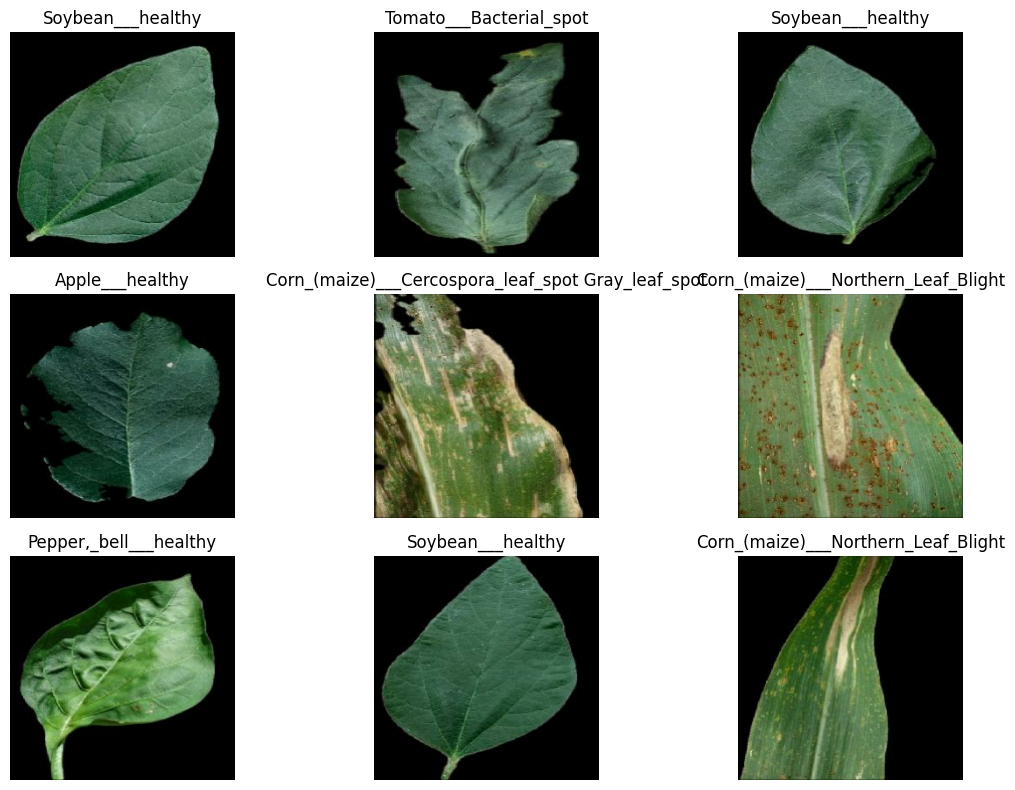

In [13]:
# Display a few images from the dataset with their class labels
plt.figure(figsize=(12, 8))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Check Class Distribution

In [14]:
# Count images available in each disease class
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(IMAGE_DIR, class_name)
    class_counts[class_name] = len(
        [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    )

class_distribution = pd.Series(class_counts).sort_values(ascending=False)

print(class_distribution)

Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                                  1404
Grape___Esca_(Black_Measles)                          1384
Corn_(maize)___Common_rust_                           1192
Grape___Black_rot                                     11

## Plot Class Distribution

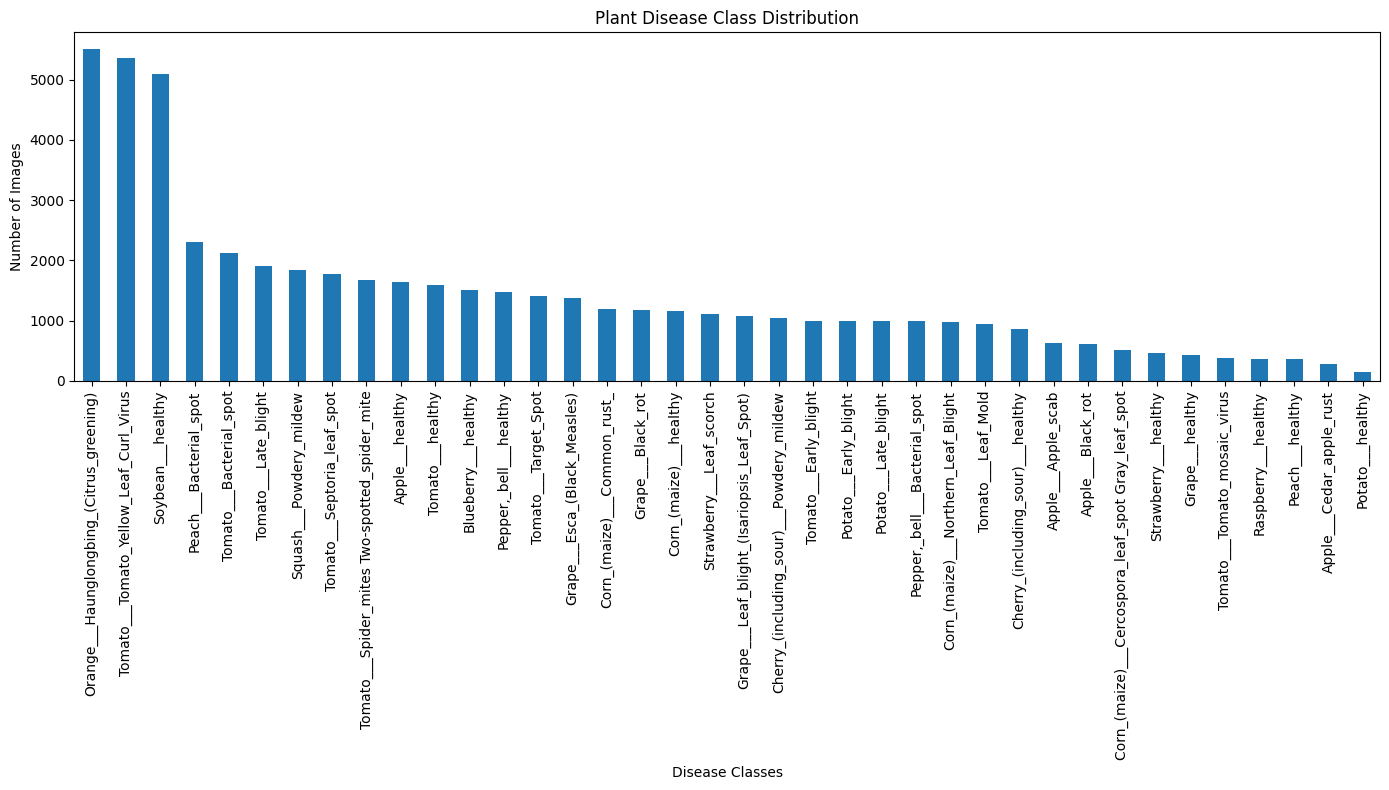

In [15]:
# Visualize the number of images in each class
plt.figure(figsize=(14, 8))

class_distribution.sort_values(ascending=False).plot(kind="bar")

plt.title("Plant Disease Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Check Image Shape and Pixel Range

In [16]:
# Check the shape and pixel value range of sample images
for images, labels in dataset.take(1):
    print("Image shape:", images[0].shape)
    print("Pixel value range:", images[0].numpy().min(), "to", images[0].numpy().max())

Image shape: (224, 224, 3)
Pixel value range: 0.0 to 249.43886


## Check Corrupted Images|

In [17]:
from PIL import Image

corrupted_images = []
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

# Check only image files and stop at the first corrupted file
for root, dirs, files in os.walk(IMAGE_DIR):
    for file in files:
        file_path = os.path.join(root, file)

        if os.path.splitext(file)[1].lower() not in valid_extensions:
            continue

        try:
            with Image.open(file_path) as img:
                img.load()
        except Exception:
            corrupted_images.append(file_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


## Check Duplicate Images

In [18]:
import hashlib

image_hashes = set()
duplicate_count = 0

# Compare image file hashes to find exact duplicates
for root, dirs, files in os.walk(IMAGE_DIR):
    for file in files:
        file_path = os.path.join(root, file)

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        with open(file_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in image_hashes:
            duplicate_count += 1
        else:
            image_hashes.add(file_hash)

print("Total unique images:", len(image_hashes))
print("Exact duplicate images:", duplicate_count)

Total unique images: 54285
Exact duplicate images: 21


## Remove Exact Duplicates

In [19]:
import shutil

WORKING_DIR = "/kaggle/working/plantvillage"

# Copy the complete 38-class dataset to a writable location
if not os.path.exists(WORKING_DIR):
    shutil.copytree(IMAGE_DIR, WORKING_DIR)

print("Working dataset created.")
print("Location:", WORKING_DIR)
print("Classes:", len(os.listdir(WORKING_DIR)))

Working dataset created.
Location: /kaggle/working/plantvillage
Classes: 38


In [20]:
# Check whether the writable dataset folder was created
print(os.path.exists(WORKING_DIR))
print(os.listdir("/kaggle/working/"))

True
['plantvillage']


In [21]:
import hashlib

seen_hashes = set()
duplicate_files = []

# Find exact duplicate images in the writable dataset
for root, dirs, files in os.walk(WORKING_DIR):
    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        file_path = os.path.join(root, file)

        with open(file_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in seen_hashes:
            duplicate_files.append(file_path)
        else:
            seen_hashes.add(file_hash)

# Remove only duplicate copies
for file_path in duplicate_files:
    os.remove(file_path)

print("Duplicate images removed:", len(duplicate_files))
print("Images remaining:", len(seen_hashes))

Duplicate images removed: 21
Images remaining: 54285


## Verify Cleaned Dataset

In [22]:
# Recount images after duplicate removal
class_counts_clean = {}

for class_name in sorted(os.listdir(WORKING_DIR)):
    class_path = os.path.join(WORKING_DIR, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        class_counts_clean[class_name] = image_count

print("Total Classes:", len(class_counts_clean))
print("Total Images:", sum(class_counts_clean.values()))

Total Classes: 38
Total Images: 54285


## Check Image Channels

In [23]:
from PIL import Image

channel_counts = {}

# Check whether images are RGB, grayscale, RGBA, etc.
for root, dirs, files in os.walk(WORKING_DIR):
    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                mode = img.mode
                channel_counts[mode] = channel_counts.get(mode, 0) + 1
        except Exception:
            pass

print("Image modes:")
for mode, count in channel_counts.items():
    print(f"{mode}: {count}")

Image modes:
RGB: 54284
L: 1


## Check Image Dimensions

In [24]:
from collections import Counter

image_sizes = Counter()

# Check dimensions of all images in the cleaned dataset
for root, dirs, files in os.walk(WORKING_DIR):
    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                image_sizes[img.size] += 1
        except Exception:
            pass

print("Different image sizes:", len(image_sizes))

for size, count in image_sizes.most_common(10):
    print(f"{size}: {count}")

Different image sizes: 5
(256, 256): 54281
(470, 512): 1
(335, 512): 1
(466, 512): 1
(324, 512): 1


## Check Image Formats

In [25]:
from collections import Counter

format_counts = Counter()

# Check the file format distribution
for root, dirs, files in os.walk(WORKING_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            extension = os.path.splitext(file)[1].lower()
            format_counts[extension] += 1

print("Image formats:")

for extension, count in format_counts.items():
    print(f"{extension}: {count}")

Image formats:
.jpg: 54285


## Analyze Class Imbalance

In [26]:
# Analyze the minimum, maximum, and average images per class
class_counts = pd.Series(class_counts_clean)

print("Minimum images:", class_counts.min())
print("Maximum images:", class_counts.max())
print("Average images:", round(class_counts.mean(), 2))

print("\nSmallest classes:")
print(class_counts.sort_values().head(10))

print("\nLargest classes:")
print(class_counts.sort_values(ascending=False).head(10))

Minimum images: 152
Maximum images: 5507
Average images: 1428.55

Smallest classes:
Potato___healthy                                      152
Apple___Cedar_apple_rust                              275
Peach___healthy                                       360
Raspberry___healthy                                   371
Tomato___Tomato_mosaic_virus                          373
Grape___healthy                                       423
Strawberry___healthy                                  456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    513
Apple___Black_rot                                     621
Apple___Apple_scab                                    630
dtype: int64

Largest classes:
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight               

## Visualize Class Imbalance

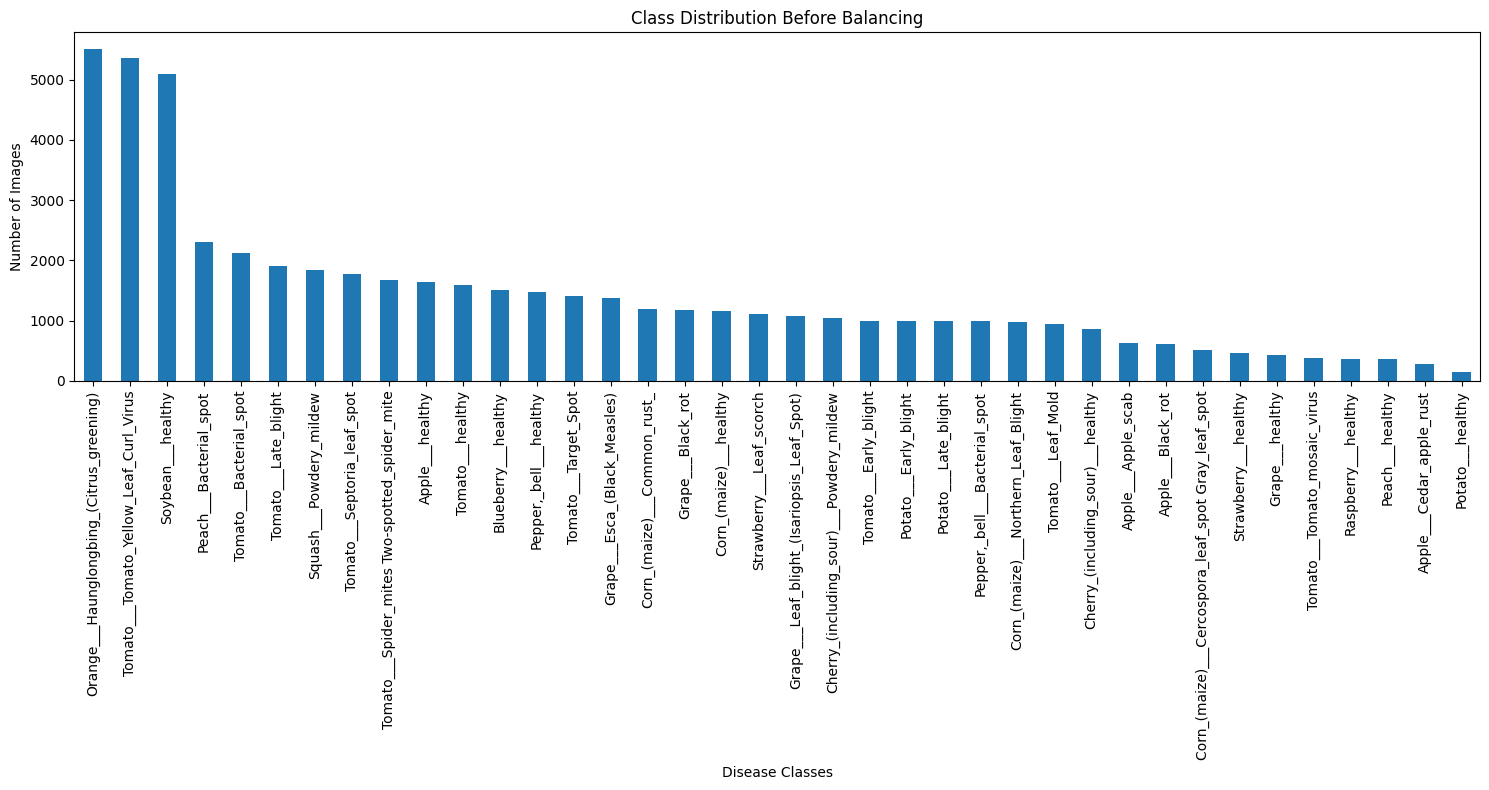

In [27]:
# Visualize the class imbalance before data splitting
plt.figure(figsize=(15, 8))

class_counts.sort_values(ascending=False).plot(kind="bar")

plt.title("Class Distribution Before Balancing")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Create Image DataFrame

In [28]:
from sklearn.model_selection import train_test_split

# Store every image path with its class label
image_paths = []
labels = []

for class_name in sorted(os.listdir(WORKING_DIR)):
    class_path = os.path.join(WORKING_DIR, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.lower().endswith(".jpg"):
                image_paths.append(os.path.join(class_path, file))
                labels.append(class_name)

data_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images:", len(data_df))
print("Total classes:", data_df["label"].nunique())

Total images: 54285
Total classes: 38


## Stratified Train / Validation / Test Split

In [30]:
# Keep the same class proportion in train, validation, and test sets
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.20,
    stratify=data_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 43428
Validation images: 5428
Testing images: 5429


## Verify Class Distribution After Split

In [31]:
# Check whether all 38 classes are properly represented in each split
train_counts = train_df["label"].value_counts().sort_index()
val_counts = val_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

print(split_distribution)

                                                    Train  Validation  Test
label                                                                      
Apple___Apple_scab                                    504          63    63
Apple___Black_rot                                     497          62    62
Apple___Cedar_apple_rust                              220          28    27
Apple___healthy                                      1310         164   164
Blueberry___healthy                                  1201         150   151
Cherry_(including_sour)___Powdery_mildew              842         105   105
Cherry_(including_sour)___healthy                     683          86    85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    410          52    51
Corn_(maize)___Common_rust_                           954         119   119
Corn_(maize)___Northern_Leaf_Blight                   788          99    98
Corn_(maize)___healthy                                930         116   116
Grape___Blac

## Calculate Class Weights

In [32]:
from sklearn.utils.class_weight import compute_class_weight

# Give higher weight to classes with fewer training images
class_indices = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

train_labels = train_df["label"].map(class_indices).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_labels
)

class_weights = {
    index: weight
    for index, weight in enumerate(weights)
}

print("Class weights calculated.")
print("Minimum weight:", round(min(weights), 3))
print("Maximum weight:", round(max(weights), 3))

Class weights calculated.
Minimum weight: 0.259
Maximum weight: 9.368


## Create TensorFlow Datasets

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

# Convert image paths and labels into TensorFlow datasets
def create_dataset(df):
    paths = df["filepath"].values
    labels = df["label"].map(class_indices).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0

        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    return ds


train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)
test_dataset = create_dataset(test_df)

print("TensorFlow datasets created.")

TensorFlow datasets created.


## Shuffle, Batch and Prefetch

In [34]:
BATCH_SIZE = 32

# Shuffle only the training data to improve learning
train_dataset = train_dataset.shuffle(
    buffer_size=1000,
    seed=SEED
)

train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

# Prefetch batches to improve training speed
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Train, validation, and test datasets are ready.")

Train, validation, and test datasets are ready.


## Data Augmentation

In [35]:
# Apply augmentation only to training images
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

print("Data augmentation ready.")

Data augmentation ready.


## Final Dataset Count Check

In [36]:
# Verify the number of images in each split before augmentation
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("Total images:", len(train_df) + len(val_df) + len(test_df))

print("\nClasses in each split:")
print("Train:", train_df["label"].nunique())
print("Validation:", val_df["label"].nunique())
print("Test:", test_df["label"].nunique())

Training images: 43428
Validation images: 5428
Test images: 5429
Total images: 54285

Classes in each split:
Train: 38
Validation: 38
Test: 38


## Apply Data Augmentation

In [37]:
# Apply augmentation only to the training dataset
train_dataset_augmented = train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=AUTOTUNE
)

train_dataset_augmented = train_dataset_augmented.prefetch(AUTOTUNE)

print("Data augmentation applied to training dataset.")

Data augmentation applied to training dataset.


## Visualize Augmented Images|

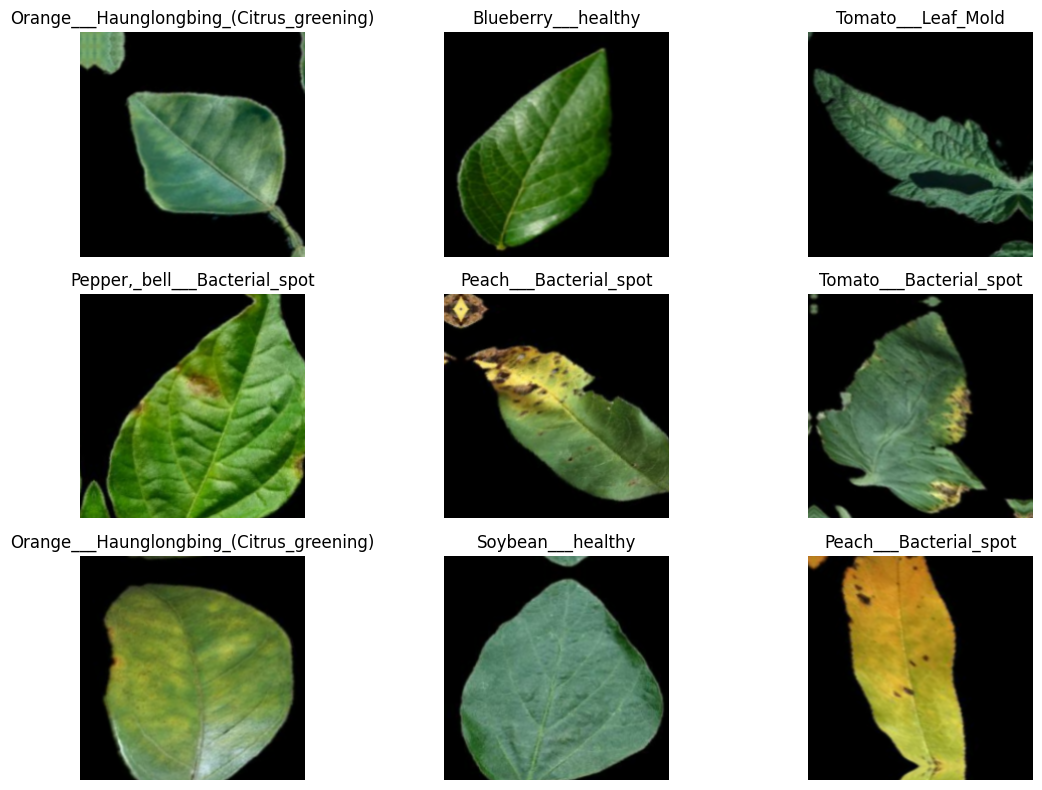

In [38]:
# Check how augmentation changes the training images
plt.figure(figsize=(12, 8))

for images, labels in train_dataset_augmented.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## DenseNet121

In [58]:
# Load DenseNet121 with ImageNet pretrained weights
base_model = keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

print("DenseNet121 loaded successfully.")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 loaded successfully.


##Freeze Pretrained Layers

In [59]:
# Freeze the pretrained DenseNet121 base
base_model.trainable = False

print("DenseNet121 pretrained layers frozen.")


DenseNet121 pretrained layers frozen.


In [60]:
densenet_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(38, activation="softmax")
])

print("DenseNet121 model created.")

DenseNet121 model created.


In [61]:
densenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("DenseNet121 compiled successfully.")


DenseNet121 compiled successfully.


In [62]:
densenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,076,454 (26.99 MB)

 Trainable params: 38,950 (152.15 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [63]:
print("Starting DenseNet121 training...")
print("-" * 60)

densenet_history = densenet_model.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("-" * 60)
print("DenseNet121 training completed.")

Starting DenseNet121 training...
------------------------------------------------------------
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 612s 427ms/step - accuracy: 0.7092 - loss: 1.1593 - val_accuracy: 0.8803 - val_loss: 0.4100 - learning_rate: 0.0010
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 546s 401ms/step - accuracy: 0.8292 - loss: 0.5855 - val_accuracy: 0.9051 - val_loss: 0.3149 - learning_rate: 0.0010
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 563s 403ms/step - accuracy: 0.8464 - loss: 0.5006 - val_accuracy: 0.9040 - val_loss: 0.3006 - learning_rate: 0.0010
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 549s 403ms/step - accuracy: 0.8538 - loss: 0.4648 - val_accuracy: 0.9141 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 552s 406ms/step - accuracy: 0.8582 - loss: 0.4475 - val_accuracy: 0.9217 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 552s 406ms/step - accuracy: 0.8609 - loss: 0.4351 - val_accuracy: 0.9036 -

## Save Trained DenseNet121 Model

In [64]:
# Save the trained DenseNet121 model
densenet_model.save("/kaggle/working/plant_disease_densenet121.keras")

print("DenseNet121 model saved successfully.")
print("Path: /kaggle/working/plant_disease_densenet121.keras")

DenseNet121 model saved successfully.
Path: /kaggle/working/plant_disease_densenet121.keras


## Save Training History

In [65]:
import pickle

# Save DenseNet121 training history
with open("/kaggle/working/densenet121_history.pkl", "wb") as f:
    pickle.dump(densenet_history.history, f)

print("Training history saved successfully.")
print("Path: /kaggle/working/densenet121_history.pkl")

Training history saved successfully.
Path: /kaggle/working/densenet121_history.pkl


## Evaluate DenseNet121 on Test Set

In [66]:
print("Evaluating DenseNet121 on test dataset...")
print("-" * 60)

test_loss, test_accuracy = densenet_model.evaluate(
    test_dataset,
    verbose=1
)

print("-" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Evaluating DenseNet121 on test dataset...
------------------------------------------------------------
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 151ms/step - accuracy: 0.9317 - loss: 0.2128
------------------------------------------------------------
Test Loss: 0.2128
Test Accuracy: 93.17%


## Classification Report

In [67]:
from sklearn.metrics import classification_report
import numpy as np

print("Generating DenseNet121 classification report...")
print("-" * 70)

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = densenet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

Generating DenseNet121 classification report...
----------------------------------------------------------------------
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9531    0.9683    0.9606        63
                                 Apple___Black_rot     0.9516    0.9516    0.9516        62
                          Apple___Cedar_apple_rust     0.8667    0.9630    0.9123        27
                                   Apple___healthy     0.8913    1.0000    0.9425       164
                               Blueberry___healthy     0.9863    0.9536    0.9697       151
          Cherry_(including_sour)___Powdery_mildew     0.9904    0.9810    0.9856       105
                 Cherry_(including_sour)___healthy     0.9770    1.0000    0.9884        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7966    0.9216    0.8545        51
                       Corn_(maize)___Common_rust_  

## Save Classification Report

In [68]:
import os

report_path = "/kaggle/working/densenet121_classification_report.txt"

with open(report_path, "w") as f:
    f.write("DenseNet121 Classification Report\n")
    f.write("=" * 70 + "\n\n")
    f.write(report)

print("Classification report saved successfully.")
print(f"Path: {report_path}")

Classification report saved successfully.
Path: /kaggle/working/densenet121_classification_report.txt


## Confusion Matrix

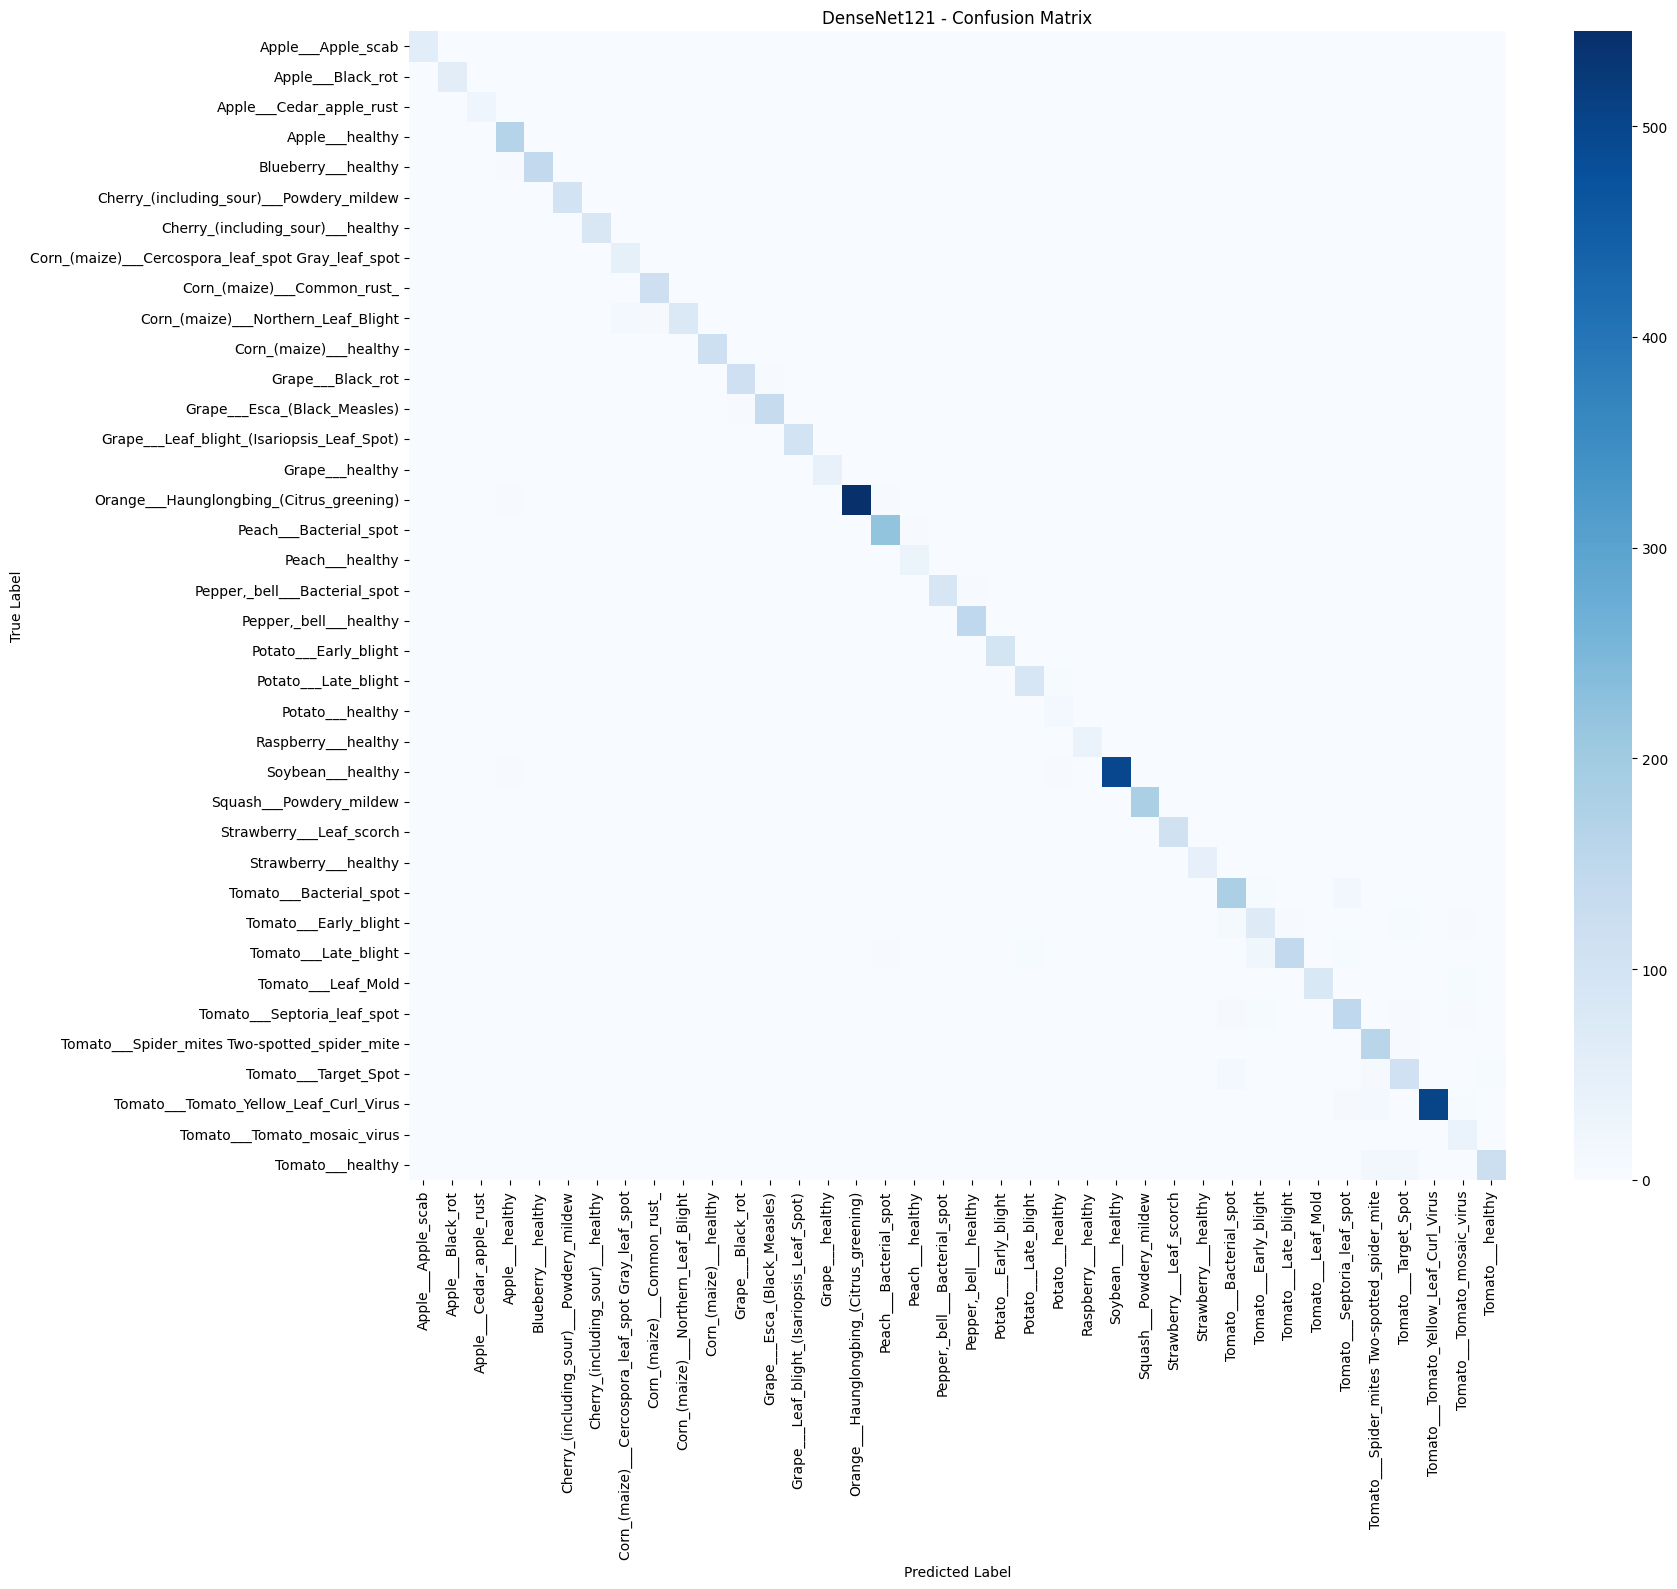

In [94]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("DenseNet121 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

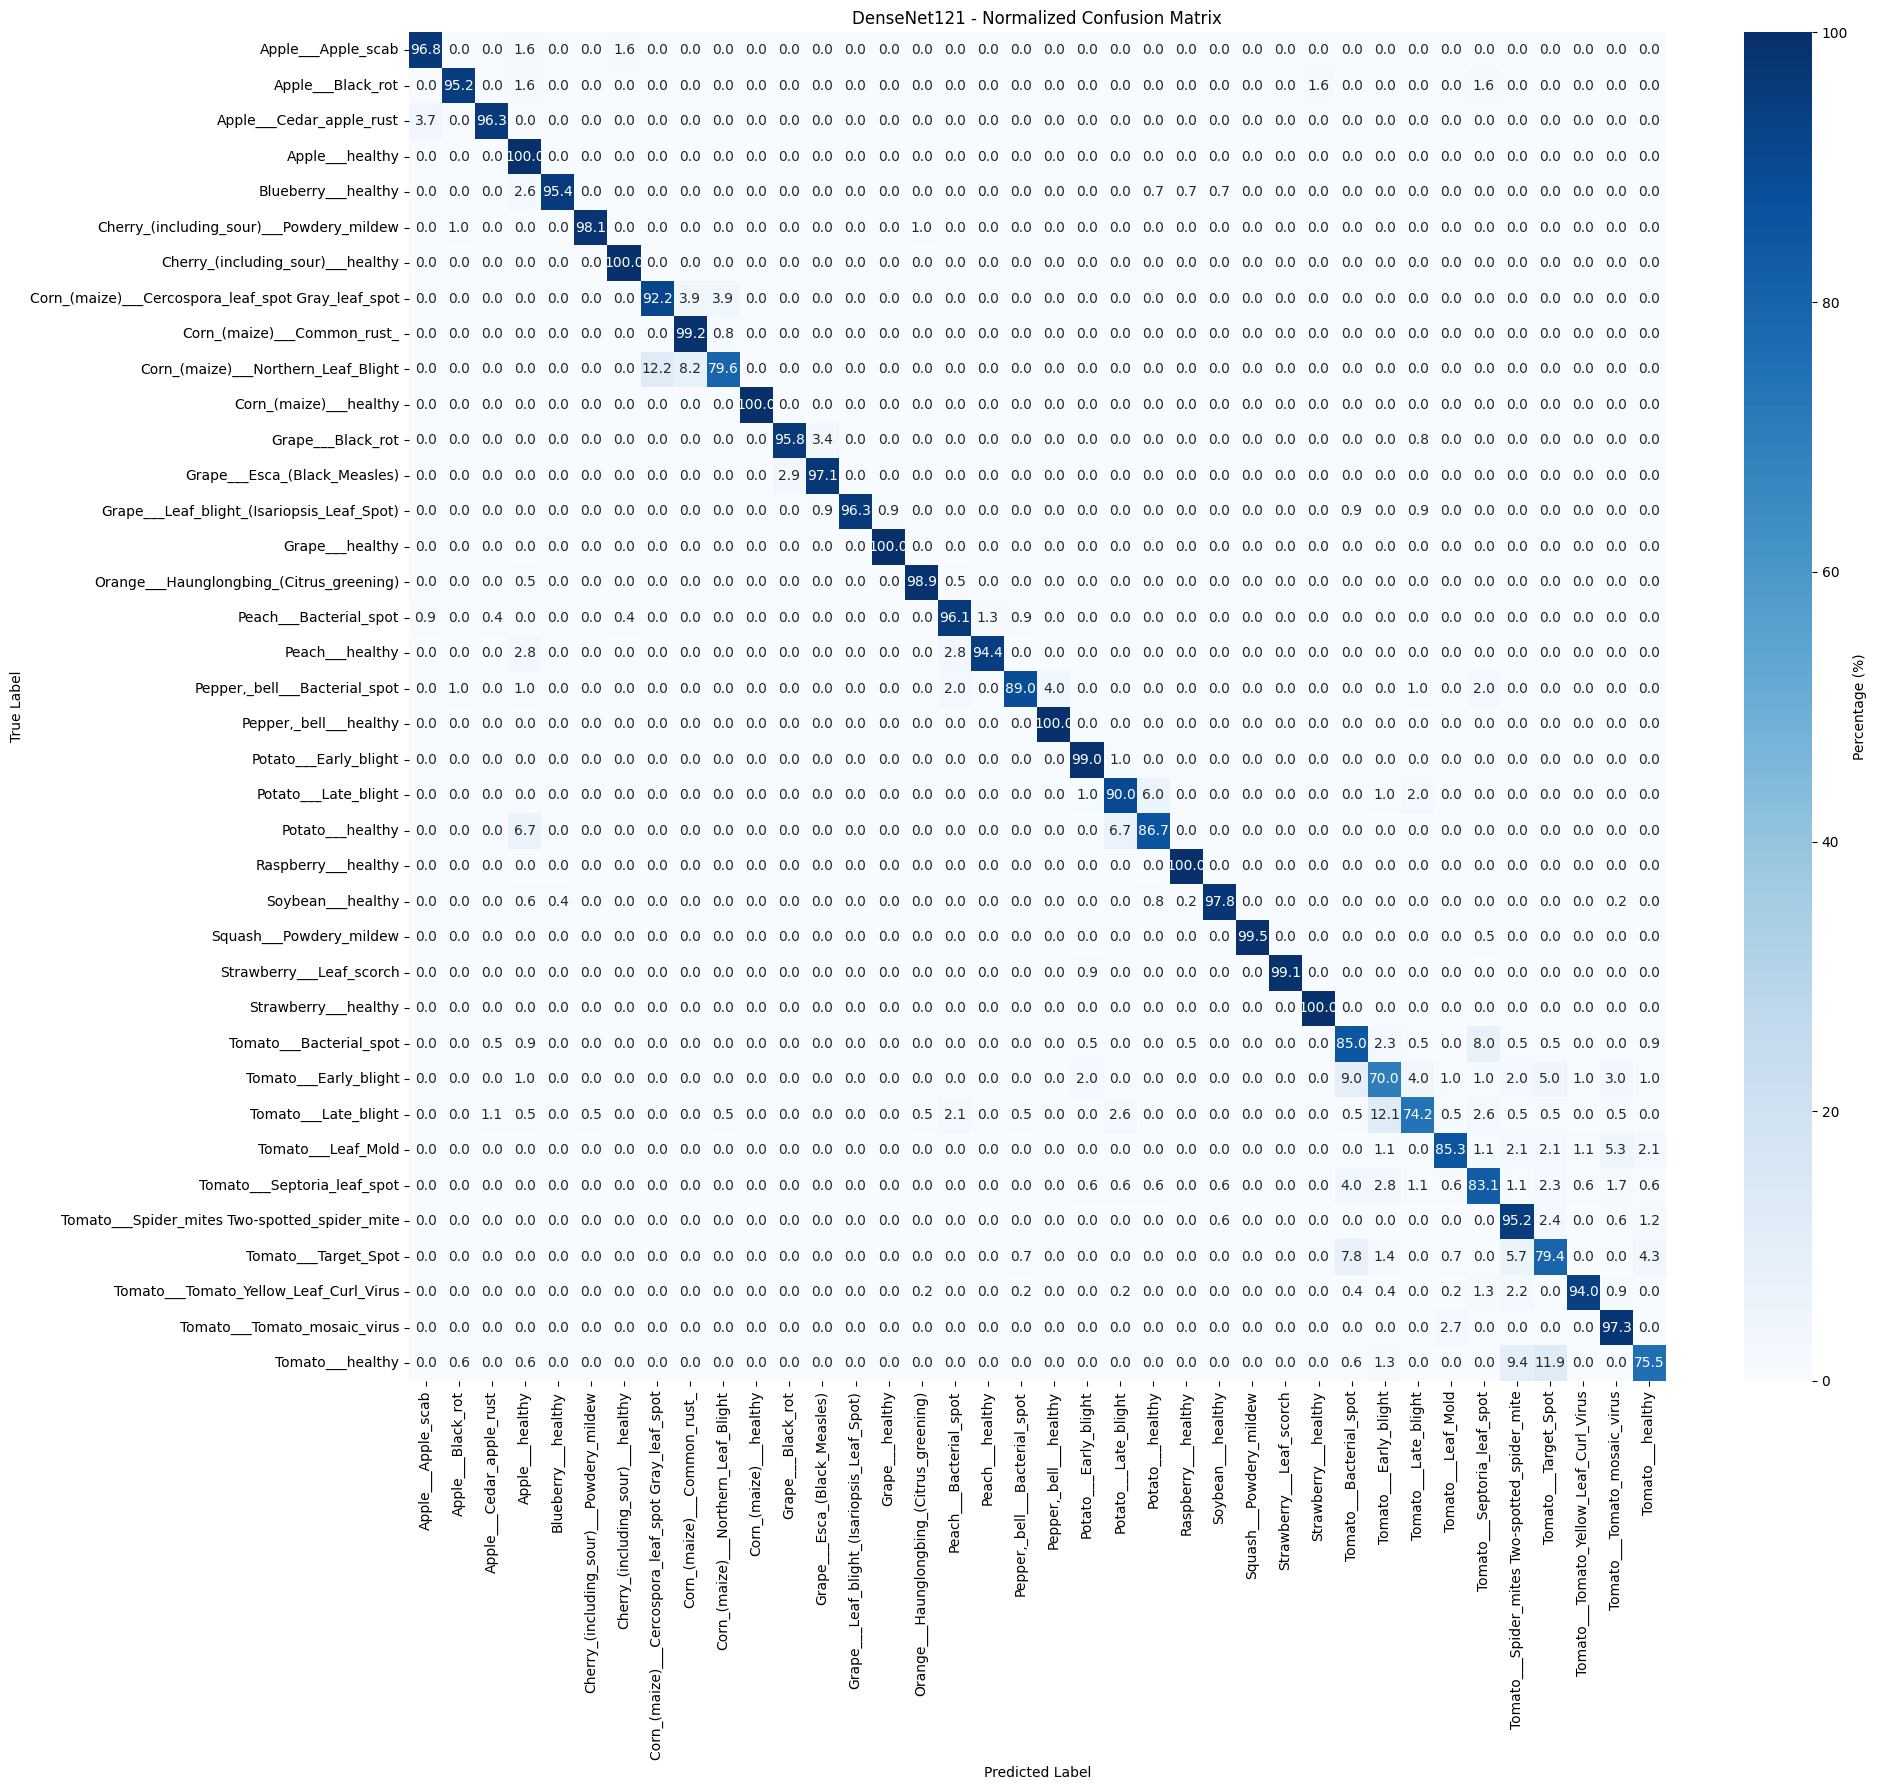

In [78]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

# Normalize each row to percentage
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Percentage (%)"}
)

plt.title("DenseNet121 - Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Training & Validation Graphs

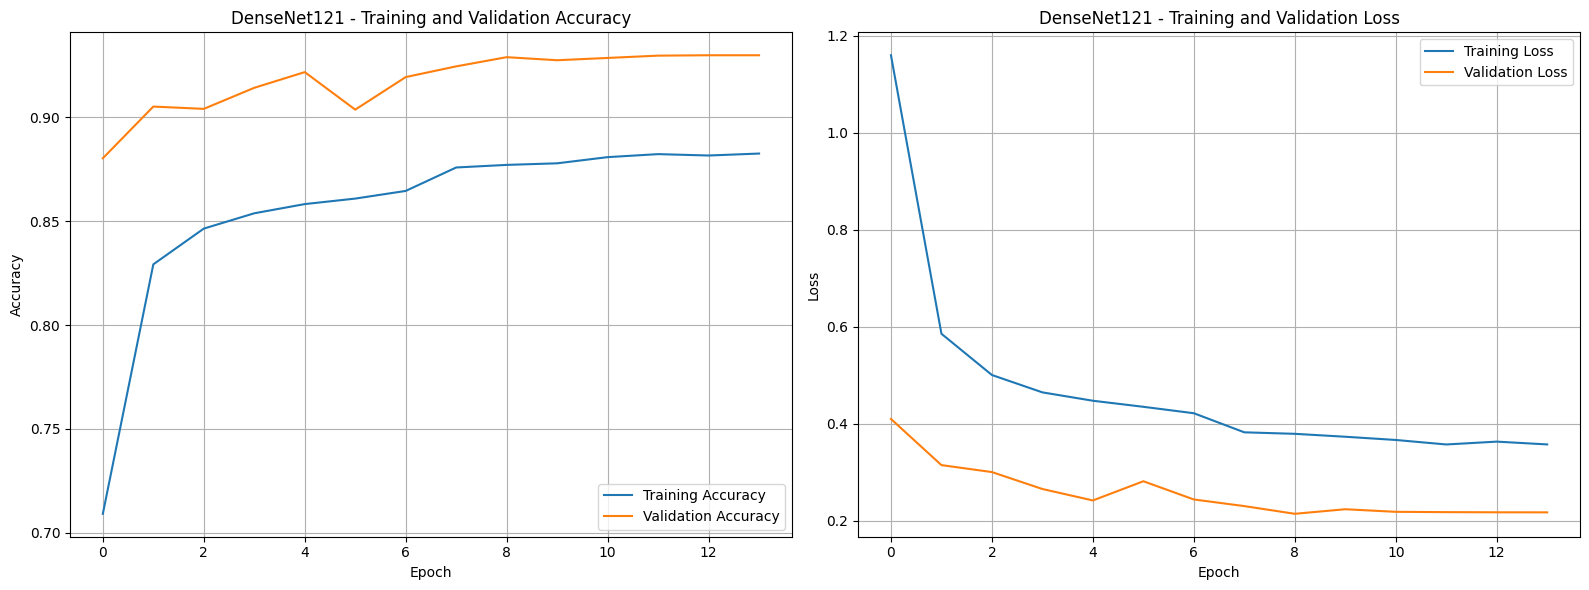

In [97]:
import matplotlib.pyplot as plt

history = densenet_history.history

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(history["accuracy"], label="Training Accuracy")
axes[0].plot(history["val_accuracy"], label="Validation Accuracy")

axes[0].set_title("DenseNet121 - Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history["loss"], label="Training Loss")
axes[1].plot(history["val_loss"], label="Validation Loss")

axes[1].set_title("DenseNet121 - Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## CNN vs DenseNet121 Comparison

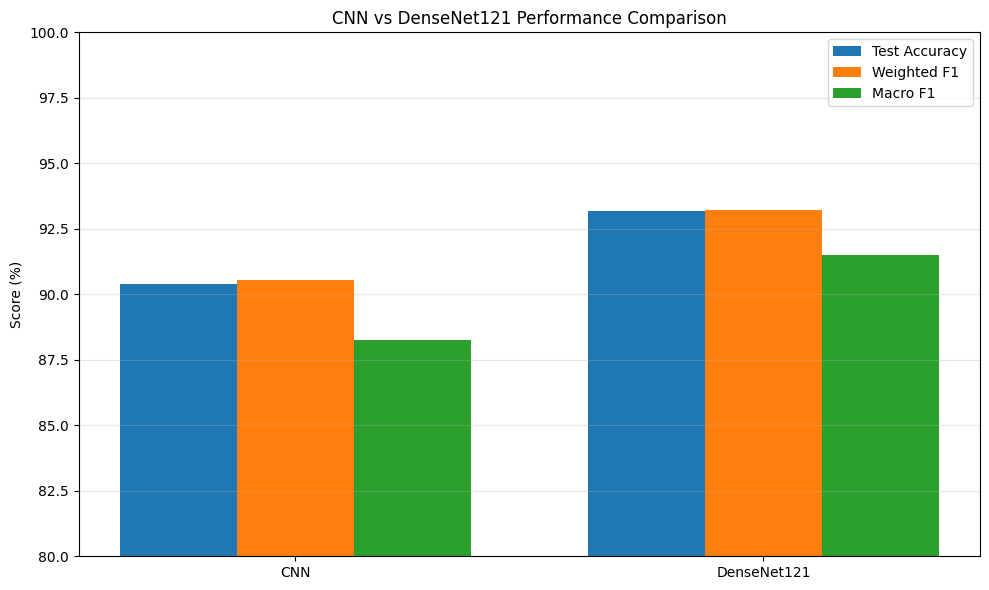

In [71]:
import matplotlib.pyplot as plt
import numpy as np

models = ["CNN", "DenseNet121"]

test_accuracy = [90.38, 93.17]
weighted_f1 = [90.53, 93.22]
macro_f1 = [88.27, 91.51]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, test_accuracy, width, label="Test Accuracy")
plt.bar(x, weighted_f1, width, label="Weighted F1")
plt.bar(x + width, macro_f1, width, label="Macro F1")

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.title("CNN vs DenseNet121 Performance Comparison")
plt.ylim(80, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

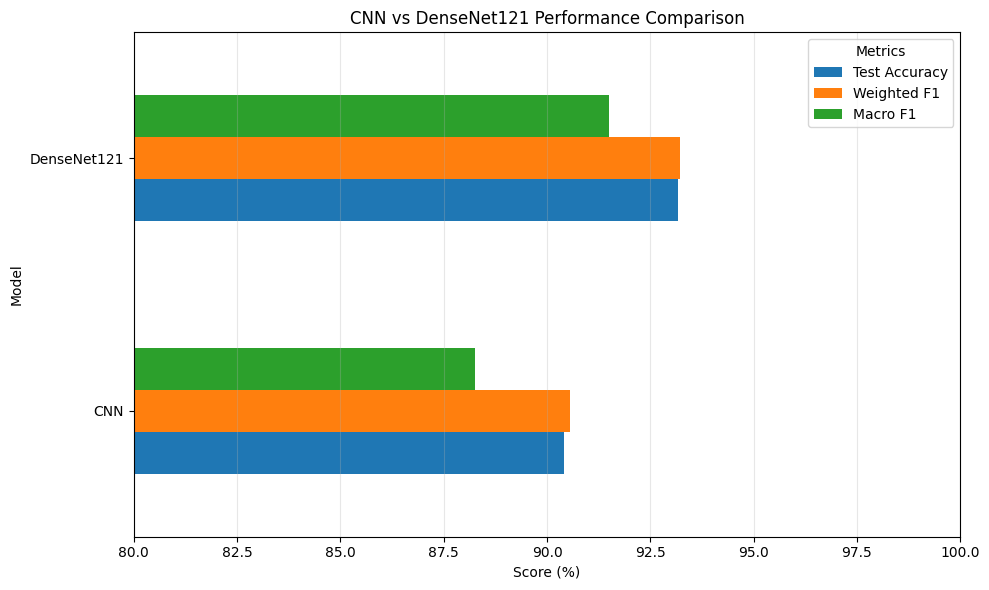

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["CNN", "DenseNet121"],
    "Test Accuracy": [90.4, 93.17],
    "Weighted F1": [90.55, 93.22],
    "Macro F1": [88.25, 91.51]
})

comparison.set_index("Model").plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("CNN vs DenseNet121 Performance Comparison")
plt.xlabel("Score (%)")
plt.ylabel("Model")
plt.xlim(80, 100)
plt.grid(axis="x", alpha=0.3)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Save Model Comparison

In [72]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN", "DenseNet121"],
    "Test Accuracy (%)": [90.38, 93.17],
    "Weighted F1 (%)": [90.53, 93.22],
    "Macro F1 (%)": [88.27, 91.51]
})

comparison.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")
print()
print(comparison.to_string(index=False))

Model comparison saved successfully.

      Model  Test Accuracy (%)  Weighted F1 (%)  Macro F1 (%)
        CNN              90.38            90.53         88.27
DenseNet121              93.17            93.22         91.51


## Single Image Prediction

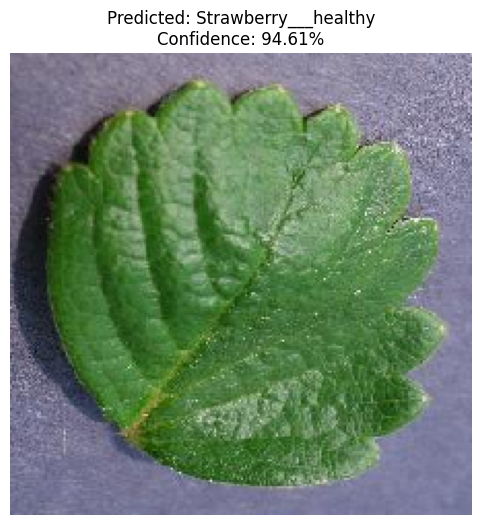

Predicted Class : Strawberry___healthy
Confidence      : 94.61%


In [95]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Image path
image_path = "/content/59f517ea-070a-4d91-97bb-936c620bbeb5___RS_HL 4583.JPG"

# Load image
image = load_img(image_path, target_size=(224, 224))

# Preprocess image
image_array = img_to_array(image) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = densenet_model.predict(image_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

# Print result
print("Predicted Class :", class_names[predicted_class])
print(f"Confidence      : {confidence:.2f}%")

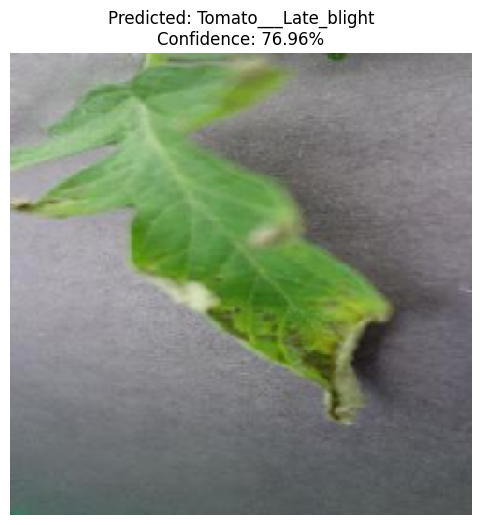

Predicted Class : Tomato___Late_blight
Confidence      : 76.96%


In [96]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Image path
image_path = "/content/a1f7a744-1d30-4343-992c-b1521d924094___GHLB2 Leaf 8563.JPG"

# Load image
image = load_img(image_path, target_size=(224, 224))

# Preprocess image
image_array = img_to_array(image) / 255.0
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = densenet_model.predict(image_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

# Print result
print("Predicted Class :", class_names[predicted_class])
print(f"Confidence      : {confidence:.2f}%")

## Save Final Evaluation Metrics

In [80]:
|import json

final_metrics = {
    "model": "DenseNet121",
    "test_accuracy": 0.9317,
    "test_loss": 0.2128,
    "weighted_f1": 0.9322,
    "macro_f1": 0.9151
}

with open("/kaggle/working/densenet121_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final evaluation metrics saved successfully.")
print(json.dumps(final_metrics, indent=4))

Final evaluation metrics saved successfully.
{
    "model": "DenseNet121",
    "test_accuracy": 0.9317,
    "test_loss": 0.2128,
    "weighted_f1": 0.9322,
    "macro_f1": 0.9151
}


In [81]:
from tensorflow.keras.models import load_model

saved_model_path = "/kaggle/working/plant_disease_densenet121.keras"

densenet_loaded = load_model(saved_model_path)

print("DenseNet121 model loaded successfully.")

DenseNet121 model loaded successfully.


In [82]:
print("Verifying saved DenseNet121 model...")
print("-" * 60)

loaded_test_loss, loaded_test_accuracy = densenet_loaded.evaluate(
    test_dataset,
    verbose=1
)

print("-" * 60)
print(f"Reloaded Model Test Loss: {loaded_test_loss:.4f}")
print(f"Reloaded Model Test Accuracy: {loaded_test_accuracy * 100:.2f}%")

Verifying saved DenseNet121 model...
------------------------------------------------------------
170/170 ━━━━━━━━━━━━━━━━━━━━ 38s 135ms/step - accuracy: 0.9317 - loss: 0.2128
------------------------------------------------------------
Reloaded Model Test Loss: 0.2128
Reloaded Model Test Accuracy: 93.17%


In [91]:
import shutil
import os

src = "/kaggle/working/plant_disease_densenet121_final.zip"
dst = "/content/plant_disease_densenet121_final.zip"

shutil.copy2(src, dst)

print("ZIP copied to Colab successfully.")
print("Size:", round(os.path.getsize(dst) / (1024 * 1024), 2), "MB")

ZIP copied to Colab successfully.
Size: 25.63 MB


In [92]:
from google.colab import files

files.download("/content/plant_disease_densenet121_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

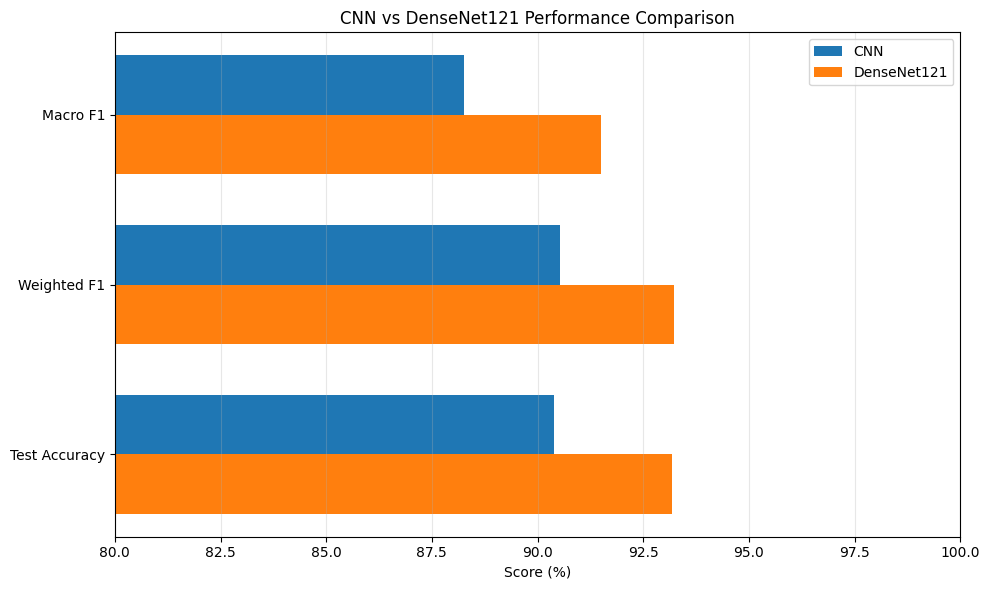

In [99]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Test Accuracy", "Weighted F1", "Macro F1"]

cnn_scores = [90.38, 90.53, 88.27]
densenet_scores = [93.17, 93.22, 91.51]

y = np.arange(len(metrics))
height = 0.35

plt.figure(figsize=(10, 6))

plt.barh(y + height/2, cnn_scores, height, label="CNN")
plt.barh(y - height/2, densenet_scores, height, label="DenseNet121")

plt.yticks(y, metrics)
plt.xlabel("Score (%)")
plt.title("CNN vs DenseNet121 Performance Comparison")
plt.xlim(80, 100)

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Build CNN Model

In [ ]:
# Build a CNN model for 38-class plant disease classification
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(38, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [ ]:
# Configure the model for multi-class classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Train the CNN Model

In [ ]:
# Train the model using augmented images and class weights
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 557s 399ms/step - accuracy: 0.1851 - loss: 2.8669 - val_accuracy: 0.4059 - val_loss: 1.8985 - learning_rate: 0.0010
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 533s 391ms/step - accuracy: 0.3750 - loss: 2.0110 - val_accuracy: 0.6253 - val_loss: 1.2303 - learning_rate: 0.0010
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 565s 394ms/step - accuracy: 0.5012 - loss: 1.5938 - val_accuracy: 0.7310 - val_loss: 0.8543 - learning_rate: 0.0010
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 555s 388ms/step - accuracy: 0.5804 - loss: 1.3246 - val_accuracy: 0.7677 - val_loss: 0.7403 - learning_rate: 0.0010
Epoch 5/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 568s 394ms/step - accuracy: 0.6322 - loss: 1.1718 - val_accuracy: 0.8055 - val_loss: 0.6134 - learning_rate: 0.0010
Epoch 6/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 535s 393ms/step - accuracy: 0.6778 - loss: 1.0158 - val_accuracy: 0.8360 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 7/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 529s 388ms

## Plot Training & Validation Performance

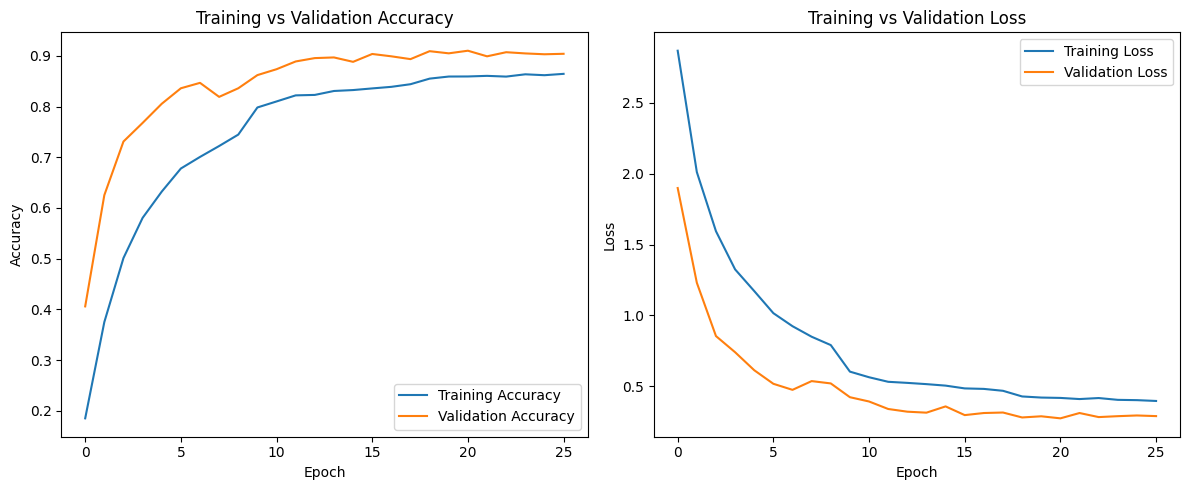

In [ ]:
# Plot accuracy and loss recorded during training
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Save Final Trained Model

In [ ]:
# Save the best trained model and training information
MODEL_PATH = "/kaggle/working/plant_disease_cnn.keras"
model.save(MODEL_PATH)

# Save class names and training history for later use
np.save("/kaggle/working/class_names.npy", class_names)
np.save("/kaggle/working/training_history.npy", history.history)

print("Model saved:", MODEL_PATH)
print("Class names saved.")
print("Training history saved.")

Model saved: /kaggle/working/plant_disease_cnn.keras
Class names saved.
Training history saved.


## Evaluate Model on Test Set

In [ ]:
# Evaluate the best saved model on unseen test images
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9038 - loss: 0.3089
Test Loss: 0.3089
Test Accuracy: 90.38 %


## Generate Predictions

In [ ]:
# Generate predictions for all unseen test images
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])
y_pred = np.argmax(model.predict(test_dataset), axis=1)

print("Predictions generated.")
print("Test samples:", len(y_true))

170/170 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step
Predictions generated.
Test samples: 5429


## Confusion Matrix

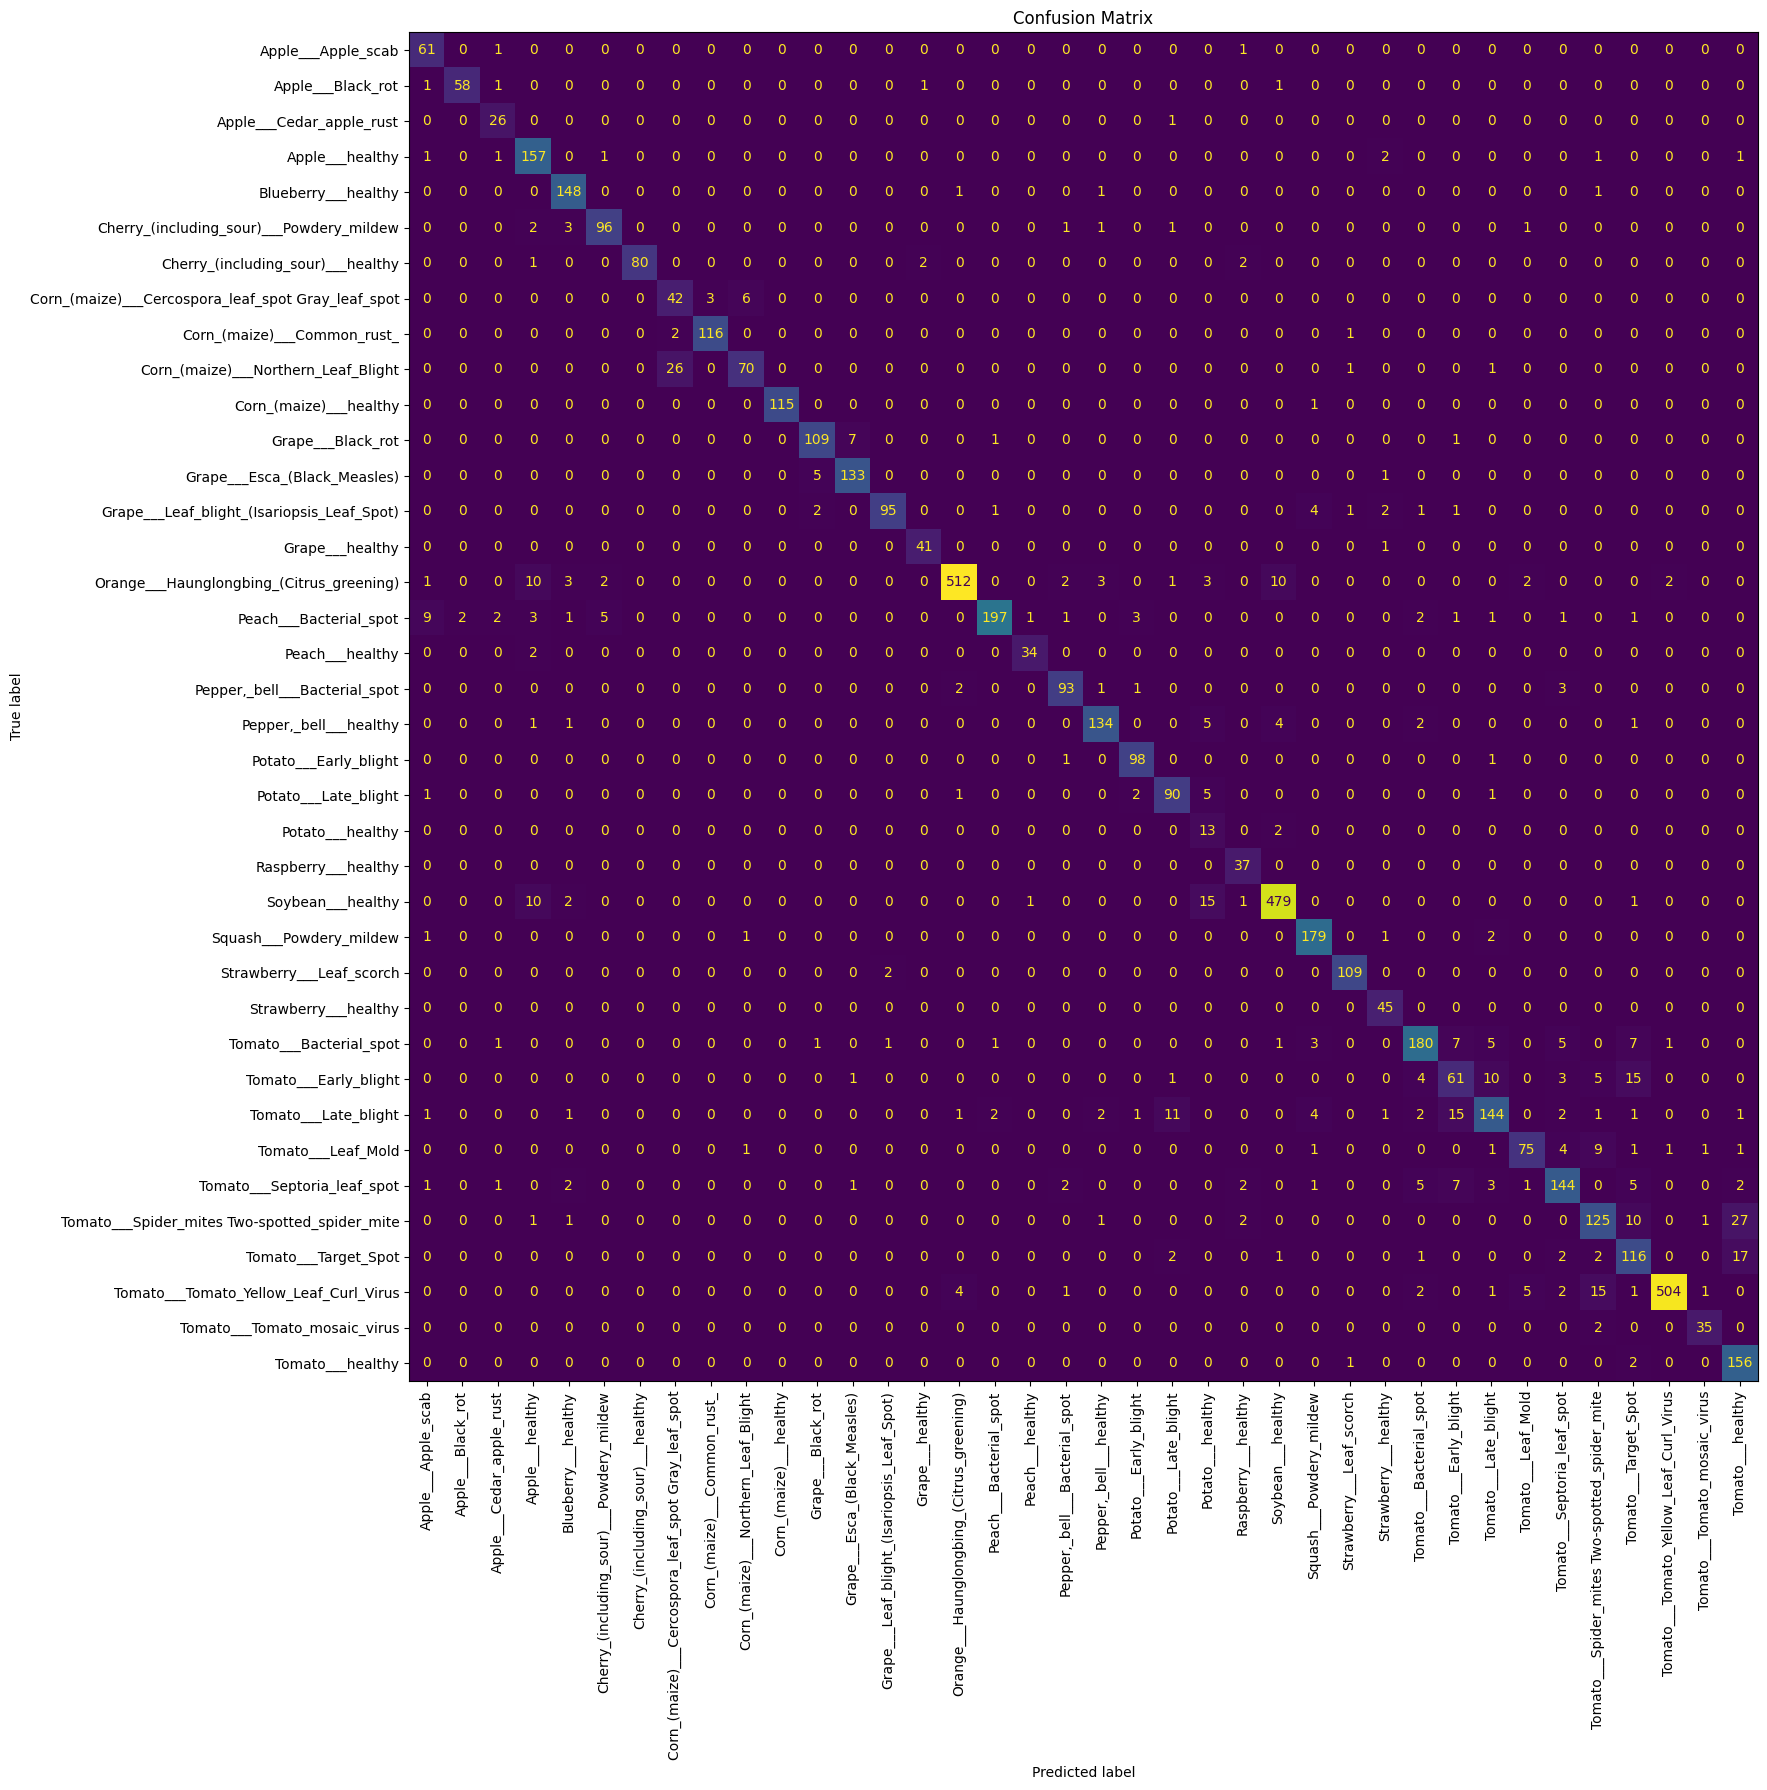

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix from true and predicted labels
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    xticks_rotation=90,
    ax=plt.gca(),
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Calculate precision, recall and F1-score for every class
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.7922    0.9683    0.8714        63
                                 Apple___Black_rot     0.9667    0.9355    0.9508        62
                          Apple___Cedar_apple_rust     0.7879    0.9630    0.8667        27
                                   Apple___healthy     0.8396    0.9573    0.8946       164
                               Blueberry___healthy     0.9136    0.9801    0.9457       151
          Cherry_(including_sour)___Powdery_mildew     0.9231    0.9143    0.9187       105
                 Cherry_(including_sour)___healthy     1.0000    0.9412    0.9697        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.6000    0.8235    0.6942        51
                       Corn_(maize)___Common_rust_     0.9748    0.9748    0.9748       119
               Corn_(maize)___Northern_Leaf_Blight     0.8974    0.7143    0.79

## Download Trained CNN

In [ ]:
from IPython.display import FileLink
import shutil

# Pack the trained model and supporting files into one ZIP
shutil.make_archive(
    "/kaggle/working/plant_disease_cnn_backup",
    "zip",
    "/kaggle/working",
    "plant_disease_cnn.keras"
)

FileLink("/kaggle/working/plant_disease_cnn_backup.zip")

/kaggle/working/plant_disease_cnn_backup.zip

In [ ]:
import os
import shutil
from IPython.display import FileLink

BACKUP_DIR = "/kaggle/working/cnn_backup"
os.makedirs(BACKUP_DIR, exist_ok=True)

# Copy all files needed to reuse the trained model
shutil.copy("/kaggle/working/plant_disease_cnn.keras", BACKUP_DIR)
shutil.copy("/kaggle/working/class_names.npy", BACKUP_DIR)
shutil.copy("/kaggle/working/training_history.npy", BACKUP_DIR)

shutil.make_archive(
    "/kaggle/working/plant_disease_cnn_backup",
    "zip",
    BACKUP_DIR
)

FileLink("/kaggle/working/plant_disease_cnn_backup.zip")

/kaggle/working/plant_disease_cnn_backup.zip

In [ ]:
import os

# Check that the backup ZIP exists
path = "/kaggle/working/plant_disease_cnn_backup.zip"

print("Exists:", os.path.exists(path))
print("Size (MB):", round(os.path.getsize(path) / (1024 * 1024), 2))


Exists: True
Size (MB): 96.14


In [ ]:
from IPython.display import FileLink

# Create a direct download link for the backup ZIP
FileLink("/kaggle/working/plant_disease_cnn_backup.zip")

/kaggle/working/plant_disease_cnn_backup.zip

In [ ]:
from IPython.display import display
from IPython.display import HTML

# Generate a browser download link
file_path = "/kaggle/working/plant_disease_cnn_backup.zip"

display(HTML(
    f'<a href="file://{file_path}" download>⬇️ Download CNN Backup ZIP</a>'
))